<a href="https://colab.research.google.com/github/Jhonny12345678-stack/Ejercicio-GITH/blob/main/regresion_logistica_creditos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de aprobación de créditos mediante Regresión Logística

**Ejercicio aplicado de clasificación con Python y Scikit-learn**

El presente proyecto tiene como objetivo desarrollar un modelo de Regresión Logística para predecir la aprobación o no aprobación de una solicitud de crédito a partir de diferentes características de la persona que lo solicita.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Mediante los anteriores comandos se han importado las respectivas librerías.
A continuación, se creará el dataset, con 100 solicitudes de crédito generadas, con las variables edad, ingreso_mensual, antiguedad_laboral, deuda_mensual y aprobado; el 1 significa aprobado y el 0 significa no aprobado.

In [ ]:
np.random.seed(42)

n = 100

edad = np.random.randint(20, 61, n)
ingreso_mensual = np.random.randint(1200000, 6000001, n)
antiguedad_laboral = np.random.randint(0, 16, n)
deuda_mensual = np.random.randint(200000, 2500001, n)

puntaje = (
    0.0000015 * ingreso_mensual
    + 0.15 * antiguedad_laboral
    + 0.03 * edad
    - 0.0000012 * deuda_mensual
)

aprobado = (puntaje > 3.5).astype(int)

df = pd.DataFrame({
    'edad': edad,
    'ingreso_mensual': ingreso_mensual,
    'antiguedad_laboral': antiguedad_laboral,
    'deuda_mensual': deuda_mensual,
    'aprobado': aprobado
})

df.head()

,edad,ingreso_mensual,antiguedad_laboral,deuda_mensual,aprobado
0,58,4721441,9,307450,1
1,48,5745583,2,2469042,1
2,34,3070230,14,2183509,1
3,27,4947389,2,316381,1
4,40,5342807,3,1721701,1


En la anterior tablas se ven 5 personas, pero se han creado 100 registros,las 5 son la aprte visual.

In [ ]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   edad                100 non-null    int64
 1   ingreso_mensual     100 non-null    int64
 2   antiguedad_laboral  100 non-null    int64
 3   deuda_mensual       100 non-null    int64
 4   aprobado            100 non-null    int64
dtypes: int64(5)
memory usage: 4.0 KB


In [ ]:
# Estadísticas descriptivas
df.describe()

,edad,ingreso_mensual,antiguedad_laboral,deuda_mensual,aprobado
count,100.00000,1.000000e+02,100.000000,1.000000e+02,100.000000
mean,38.94000,3.785575e+06,6.950000,1.382550e+06,0.860000
std,11.78153,1.399533e+06,5.057997,6.980481e+05,0.348735
min,20.00000,1.239353e+06,0.000000,2.030510e+05,0.000000
25%,28.00000,2.751572e+06,2.000000,8.489392e+05,1.000000
50%,39.50000,3.919365e+06,7.000000,1.386004e+06,1.000000
75%,47.25000,5.021169e+06,11.000000,1.964877e+06,1.000000
max,60.00000,5.893350e+06,15.000000,2.494544e+06,1.000000


In [ ]:
# Verificar valores faltantes
df.isnull().sum()

,0
edad,0
ingreso_mensual,0
antiguedad_laboral,0
deuda_mensual,0
aprobado,0


La anterior tabla , la cual tiene ceros, indica que no hay valores faltantes.

Ver cuántas solicitudes fueron aprobadas y cuántas no:

In [ ]:
# Cantidad de solicitudes aprobadas y no aprobadas
df['aprobado'].value_counts()

,count
aprobado,
1,86
0,14


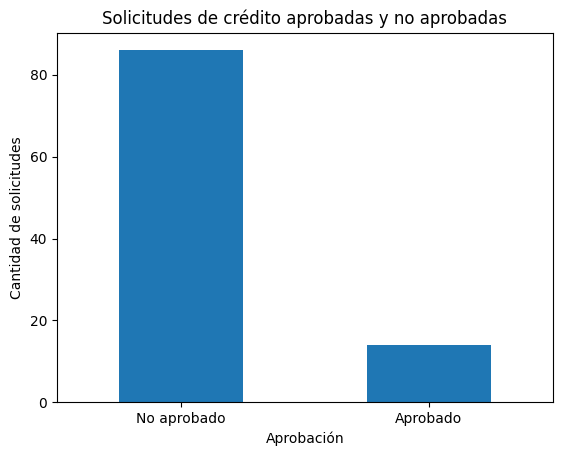

In [ ]:
# Gráfico de solicitudes aprobadas y no aprobadas

df['aprobado'].value_counts().plot(kind='bar')

plt.title('Solicitudes de crédito aprobadas y no aprobadas')
plt.xlabel('Aprobación')
plt.ylabel('Cantidad de solicitudes')
plt.xticks([0, 1], ['No aprobado', 'Aprobado'], rotation=0)

plt.show()

Como se puede ver, se han aprobado 86 solicitudes, y 14 solicitudes no se han aprobado.

Observar si exite una relación entre ingreso y aprobación:

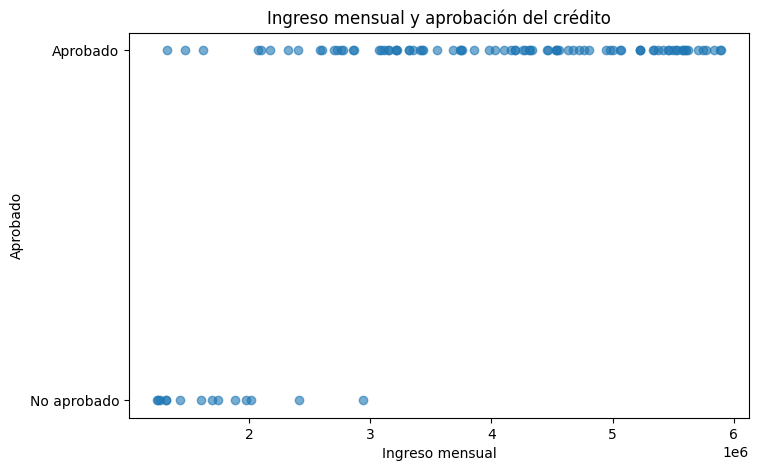

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df['ingreso_mensual'],
    df['aprobado'],
    alpha=0.6
)

plt.title('Ingreso mensual y aprobación del crédito')
plt.xlabel('Ingreso mensual')
plt.ylabel('Aprobado')

plt.yticks([0, 1], ['No aprobado', 'Aprobado'])

plt.show()

Separar variables predictoras y variable objetivo:

In [ ]:
# Variables predictoras
X = df[['edad', 'ingreso_mensual', 'antiguedad_laboral', 'deuda_mensual']]

# Variable objetivo
y = df['aprobado']

print("Variables predictoras:")
print(X.head())

print("\nVariable objetivo:")
print(y.head())

Variables predictoras:
   edad  ingreso_mensual  antiguedad_laboral  deuda_mensual
0    58          4721441                   9         307450
1    48          5745583                   2        2469042
2    34          3070230                  14        2183509
3    27          4947389                   2         316381
4    40          5342807                   3        1721701

Variable objetivo:
0    1
1    1
2    1
3    1
4    1
Name: aprobado, dtype: int64


Dividir los datos para entrenar y evaluar el modelo: 80 % datos de entrenamiento y 20 % datos de prueba.

In [ ]:
# Dividir los datos en entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape[0])
print("Datos de prueba:", X_test.shape[0])

Datos de entrenamiento: 80
Datos de prueba: 20


Crear el modelo:

In [ ]:
# Crear el modelo de Regresión Logística
modelo = LogisticRegression()

# Entrenar el modelo
modelo.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

Realizar las predicciones para las 20 solicitudes de prueba:

In [ ]:
# Realizar predicciones sobre los datos de prueba
y_pred = modelo.predict(X_test)

print("Predicciones:")
print(y_pred)

Predicciones:
[1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1]


Comparar predicciones con resultados reales:

In [ ]:
comparacion = pd.DataFrame({
    'Real': y_test.values,
    'Predicción': y_pred
})

comparacion

,Real,Predicción
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,1,1
8,0,0
9,0,0


Matriz de confusión: tabla para ver los aciertos y los errores que comete el modelo de clasificación al comparar las predicciones con los datos reales.

In [ ]:
# Matriz de confusión
matriz = confusion_matrix(y_test, y_pred)

print("Matriz de confusión:")
print(matriz)

Matriz de confusión:
[[ 2  1]
 [ 0 17]]


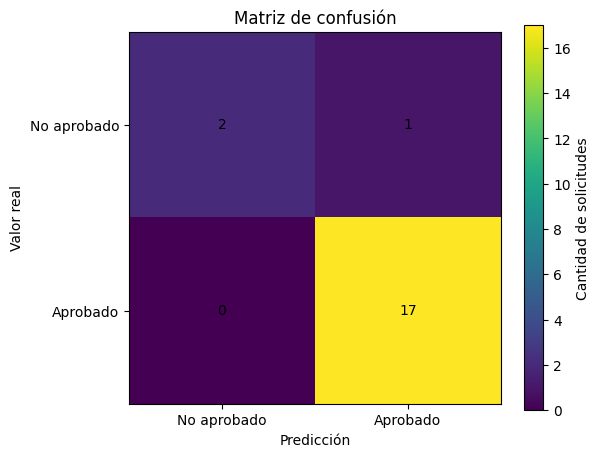

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(matriz)

plt.title('Matriz de confusión')
plt.xlabel('Predicción')
plt.ylabel('Valor real')

plt.xticks([0, 1], ['No aprobado', 'Aprobado'])
plt.yticks([0, 1], ['No aprobado', 'Aprobado'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, matriz[i, j],
                 ha='center',
                 va='center')

plt.colorbar(label='Cantidad de solicitudes')
plt.show()

Lo anterior significa que hubo:
2 verdaderos negativos (TN): Eran créditos no aprobados y el modelo los identificó correctamente.
1 falso positivo (FP): Era un crédito no aprobado, pero el modelo predijo que sí debía aprobarse.
0 falsos negativos (FN): Ningún crédito realmente aprobado fué clasificado como no aprobado.
17 verdaderos positivos (TP): Eran créditos aprobados y el modelo los identificó correctamente.
En total se tienen 20 solicitudes de prueba: 3 no aprobadas y 17 aprobadas.

Accurracy: Indica qué porción de las predicciones fueron correctas.

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.95


Significa que el modelo acertó en un 95 % de las predicciones realziadas sobre los 20 datos de prueba.

Informe de clasificación:

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.67      0.80         3
           1       0.94      1.00      0.97        17

    accuracy                           0.95        20
   macro avg       0.97      0.83      0.89        20
weighted avg       0.95      0.95      0.95        20



Obtener los coeficientes del modelo:

In [ ]:
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo.coef_[0]
})

coeficientes

,Variable,Coeficiente
0,edad,-0.025066
1,ingreso_mensual,0.000005
2,antiguedad_laboral,0.279778
3,deuda_mensual,-0.000007


De lo anterior obtenido, se tiene que:
ingreso_mensual: Tiene una relación positiva.
antiguedad_laboral: Tiene una relación positiva.
edad: Tiene una relación negativa.
deuda_mensual: Tiene una relación negativa.

Visualizar valores reales y predicciones:

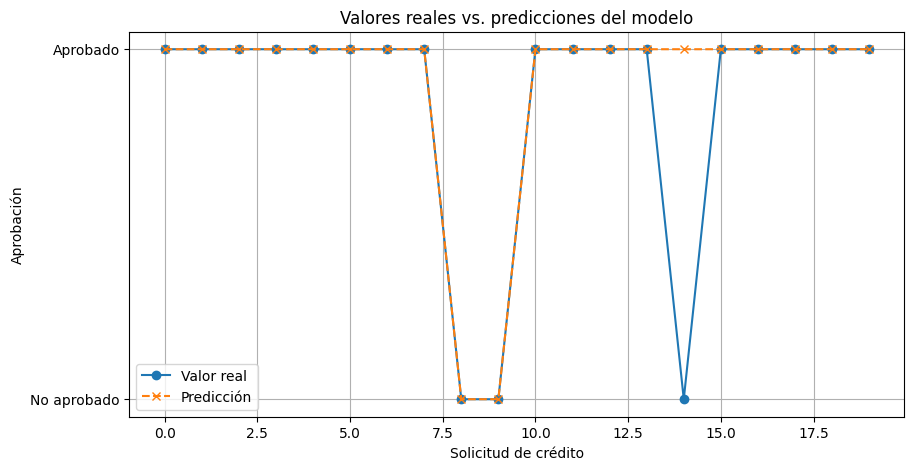

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(len(y_test)),
    y_test.values,
    'o-',
    label='Valor real'
)

plt.plot(
    range(len(y_pred)),
    y_pred,
    'x--',
    label='Predicción'
)

plt.title('Valores reales vs. predicciones del modelo')
plt.xlabel('Solicitud de crédito')
plt.ylabel('Aprobación')

plt.yticks([0, 1], ['No aprobado', 'Aprobado'])
plt.legend()
plt.grid(True)

plt.show()

Como se puede observar en la anterior gráfica,hubo 19 aciertos y 1 error, la cual es la única diferencia entre las dos líneas.  

Predicción de ejemplo:

In [ ]:
nueva_solicitud = pd.DataFrame({
    'edad': [35],
    'ingreso_mensual': [3500000],
    'antiguedad_laboral': [5],
    'deuda_mensual': [800000]
})

prediccion = modelo.predict(nueva_solicitud)

print("Predicción:", prediccion[0])

if prediccion[0] == 1:
    print("Resultado: Crédito aprobado")
else:
    print("Resultado: Crédito no aprobado")

Predicción: 1
Resultado: Crédito aprobado


Obtener la probabilidad de aprobación:

In [ ]:
probabilidad = modelo.predict_proba(nueva_solicitud)[0][1]

print(f"Probabilidad estimada de aprobación: {probabilidad:.2%}")

Probabilidad estimada de aprobación: 100.00%


                               Conclusiones

En el presente ejercicio se desarrolló un modelo de Regresión Logística, con el fin de predecir la aprobación de solicitudes de crédito a partir de variables como la edad, el ingreso mensual, la antiguedad laboral y la deuda mensual.

La prueba se compone de: Dataset simulado, exploración y descripción de datos, comprobación de valores nulos, distribución de aprobaciones, gráfica exploratoria, variables predictoras y variable objetivo, división de datos 80 % entrenamiento y 20 % prueba, entrenamiento de regresión logística, predicciones, matriz de confusión, accuracy 95 %, precisión, recall y f1 score, coeficientes del modelo, comparación gráfica de valores reales y predicciones , predicción de una nueva solicitud y probabilidad estimada de aprobación 100 %.

El modelo obtuvo un Accuracy de 95 % (esto es la métrica que mide el procentaje de predicciones correctas) sobre los datos de prueba, mediante el cual clasificó de manera correcta 19 de las 20 solicitudes evaluadas. Además, los resultados de precisión, recall y F1-score mostraron un desempeño favorable, en esepcial en los créditos aprobados.

Mediante la matriz de confusión se pudo identificar que el modelo realizó correctamente las 19 clasificaciones y solamente 1 error, también se realizó una prueba con una nueva solicitud simulada, para la cual el modelo predijo la clase de crédito aprobado y estimó una probabilidad de aprobación del 100 %.

Se trabajó mediante los datos generados artificialmente , si bien los resultados no son un sistema real, puede tomarse como referencia para una apliciación práctica.
